# Importation des librairies

In [73]:
import numpy as np
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot
import torch
from sklearn.mixture import GaussianMixture


## 1er Cas : Données 2D (D=2)  
### Génération de la distribution source (GMM 2D)  

Dans ce partie, nous générons un nuage de points suivant une **mixture gaussienne (GMM)** en 2 dimensions.  
Chaque point est assigné à un cluster selon les poids définis, et chaque cluster a une moyenne et une covariance .

In [74]:
#initialisation du générateur aléatoire 
rng = np.random.RandomState(0) 
#initialisation de nombre de points et dimension 
N = 200 # nombre de points total 
D= 2    # la dimension des données 

In [75]:
# initialisation des parametres de la GMM : poids , moyennes et covariances
K = 4 # nombre de clusters 
weights = np.array([0.4, 0.3, 0.1, 0.2]) # vecteur des poids de taille K 
means = np.array([[0, 0], [3, 3], [0, 4], [4, 0]]) # moyenne 
covs = np.array([np.eye(2) * 0.4 for _ in range(K)]) # Covariances (symetriques)


In [76]:

#  on commence par le tirage des clusters pour chaque point : chaque point on l'affecte a un cluster 
Z = rng.choice(range(K), size=N, p=weights)

# Génération des points
X = np.zeros((N,D))
for i in range(N):
    k = Z[i] #on selectionne le cluster associé 
    X[i] = np.random.multivariate_normal(means[k], covs[k])

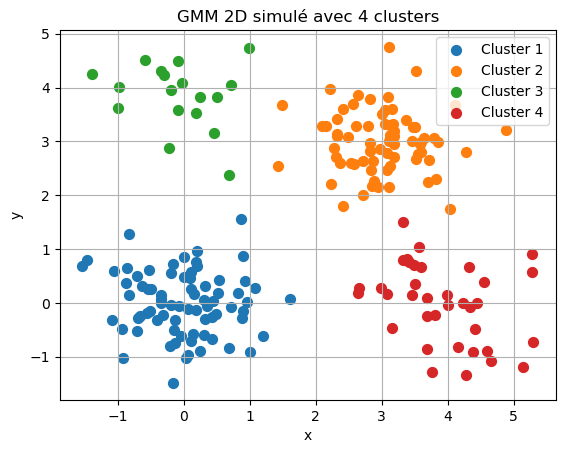

In [77]:
# Visualisation
markers = ['o', 'o', 'o','o']  

for k in range(K):
    plt.scatter(X[Z==k,0], X[Z==k,1], s=50, label=f'Cluster {k+1}', marker=markers[k])
    
plt.xlabel("x")
plt.ylabel("y")
plt.title("GMM 2D simulé avec 4 clusters")
plt.legend()
plt.grid(True)
plt.show()


## Génération de la distribution cible via l’algorithme EM  

Maintenant nous ajustons un **une GMM ** sur les données générées précédemment en utilisant l’**algorithme EM (Expectation-Maximization)**.  
L’objectif est d’estimer les **poids, moyennes et covariances** des clusters à partir des points simulés.

In [78]:

gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=0)
gmm.fit(X)

# Labels trouvé par l'algorithme EM
labels = gmm.predict(X)

# on recupere les paramètres estimés
em_weights = gmm.weights_
em_means = gmm.means_
em_covs = gmm.covariances_

#Affichage 
print("Poids estimés :", em_weights)
print("Moyennes estimées :", em_means)
print("Covariances estimées :", em_covs)


Poids estimés : [0.18061721 0.35020985 0.3747931  0.09437985]
Moyennes estimées : [[ 3.93510096  0.0047392 ]
 [ 3.03340326  2.9926775 ]
 [-0.0070519  -0.00394784]
 [-0.00436662  3.82942067]]
Covariances estimées : [[[ 0.49258385 -0.17113427]
  [-0.17113427  0.53778459]]

 [[ 0.34331687 -0.00555775]
  [-0.00555775  0.32112912]]

 [[ 0.41334476 -0.03546316]
  [-0.03546316  0.34151248]]

 [[ 0.48186171 -0.11223665]
  [-0.11223665  0.35641774]]]


C:\Users\lorie\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


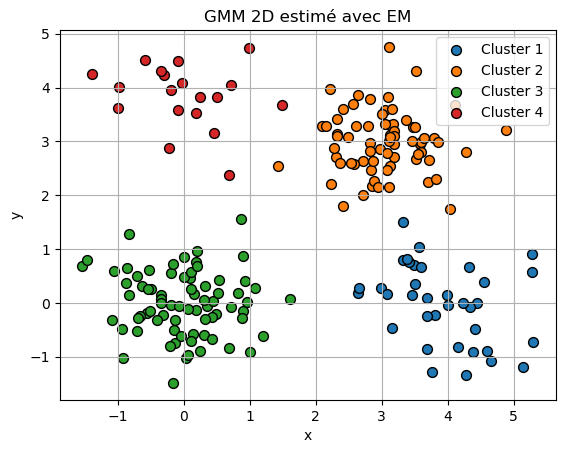

In [79]:
# Affichage des clusters trouvés par EM 
markers = ['o', 'o', 'o', 'o'] 
for k in range(K):
    plt.scatter(X[labels==k,0], X[labels==k,1], s=50, edgecolor='k',
                label=f'Cluster {k+1}', marker=markers[k])

plt.xlabel("x")
plt.ylabel("y")
plt.title("GMM 2D estimé avec EM")
plt.legend()
plt.grid(True)
plt.show()



## Estimation des poids via l’approche de Rémi Flamary

Dans cette partie, nous utilisons la méthode présentée par Rémi Flamary (*Wasserstein Unmixing with PyTorch*) pour **estimer les poids des clusters**


In [80]:
#On commence par echantilloner des points de notre distribution source trouvé par l algo em 
XS, labels_source = gmm.sample(N)

# Calcul des matrices H et J
# Ces matrices ont la taille (N, K) et représentent les poids de chaque point 
# dans chaque cluster pour chaque distribution :
#  H : distribution source (points échantillonnés via EM)
#  J : distribution cible (points originaux)

# Initialisation 
H = np.zeros((N, K)) 
J= np.zeros((N,K))


# Remplir H
for k in range(K):
    mask = (labels_source == k)  # on selectionne les points du cluster k
    n_samples_k = mask.sum()  # Nombre de points dans le cluster 
    
    if n_samples_k > 0:
        H[mask, k] = 1 / n_samples_k  # repartition uniforme sur le cluster 
        
# Remplir J 
for k in range(K):
    mask2 = (Z==k)
    n_points = mask2.sum()
    if n_points > 0 : 
        J[mask2,k]= 1/n_points
# Vérification : la somme de chaque colonne doit etre egale a 1 
print("Somme par colonne :", H.sum(axis=0))
print(H.shape)

    

Somme par colonne : [1. 1. 1. 1.]
(200, 4)


## Étape d'optimisation des poids

L'objectif ici est d'estimer les **poids des clusters de la source** afin de mieux correspondre à la **distribution cible**, en minimisant la **distance de Wasserstein**.  

Nous suivons la méthode présentée par Rémi Flamary, en utilisant **PyTorch** pour le calcul des gradients et la projection sur le simplexe.

Dans cette partie, nous **fixons les moyennes et les matrices de covariance** estimées par l’algorithme EM, et nous nous intéressons uniquement à **l’optimisation des poids**.

In [81]:
# on commence par convertir les tableaux  numpy en tenseurs PyTorch
H2 = torch.tensor(H,dtype=torch.float64)
J2 = torch.tensor(J,dtype=torch.float64)
M2 = torch.tensor(M,dtype=torch.float64)


# on initialise le vecteur des poids au poids trouvé par l'algo em 
w = torch.tensor(em_weights.copy(),requires_grad=True,dtype=torch.float64)

# Poids fixe de la distribution cible 
w_fixed = torch.tensor(weights,dtype=torch.float64)

# Calcul des poids de chaque point cible : b = J @ w_fixed
b= torch.mv(J2,w_fixed) 

# Hyperparametres
eta0 = 5e-4    # taux d'apprentissage
IterMax = 500  # nombre d'iterations 
losses = []    #  stockage des valeurs de la loss


def get_loss(w): 
    #  Calcul des poids par point pour la source
    a = torch.mv(H2,w)
    return ot.emd2(a,b,M2) # Distance de Wassertein
    
# Boucle d'optimisation 
for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
     # calcule la loss
    loss = get_loss(w)
    losses.append(float(loss))
     # calcule du gradient 
    loss.backward()
    #print("grad w =", w.grad) : pour verifier que le gradient n est pas nul 

    with torch.no_grad(): 
        # mise a jour par descente de gradient 
        w -= eta * w.grad 
        # Projection sur le simplexe 
        w[:] = ot.utils.proj_simplex(w) 
        #on remis a 0 le gradient 
        w.grad.zero_()
       

In [82]:
we = w.detach().numpy()
print("\nCOMPARAISON DES POIDS")
print("Vrais poids (cible)    :", weights)
print("Poids estimés (EM)     :", em_weights)
print("Poids optimisés (OT)   :", we)



COMPARAISON DES POIDS
Vrais poids (cible)    : [0.4 0.3 0.1 0.2]
Poids estimés (EM)     : [0.18061721 0.35020985 0.3747931  0.09437985]
Poids optimisés (OT)   : [0.23174228 0.33650863 0.33842944 0.09331965]


Text(0.5, 0, 'Iterations')

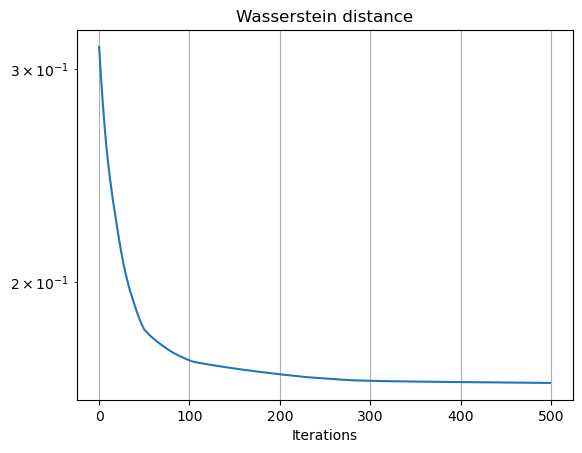

In [83]:
# Visualisation de l'évolution de la loss
pl.figure(2)
pl.semilogy(losses)
pl.grid()
pl.title("Wasserstein distance")
pl.xlabel("Iterations")

La courbe décroît et converge de manière stable, sans oscillation ni divergence, ce qui montre que cette méthode fonctionne très bien pour l’optimisation des poids des clusters.

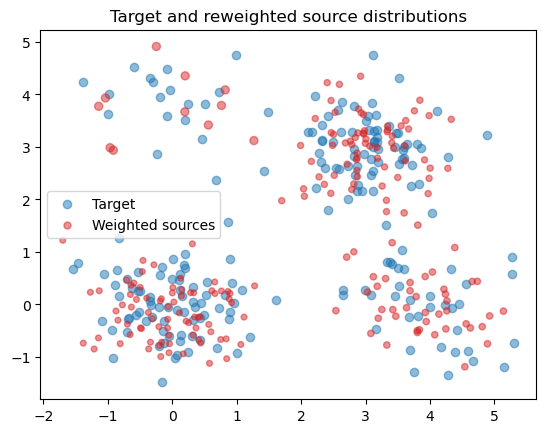

In [84]:
pl.figure(3)
ws= H @ we # Calcul des poids par point après optimisation
ws.shape
pl.scatter(X[:, 0], X[:, 1], label="Target", alpha=0.5)
pl.scatter(
    XS[:, 0],
    XS[:, 1],
    color="C3",
    s=ws * 20 * N,
    label="Weighted sources",
    alpha=0.5,
)
pl.title("Target and reweighted source distributions")
pl.legend()

On observe que certains points deviennent plus importants (plus grands), tandis que d’autres perdent en importance.

Cela montre que l’algorithme a ajusté la répartition de la masse afin de rapprocher la distribution source de la distribution cible.

## Optimisation des Moyennes par approche Monte Carlo avec reparametrization trick

Ici, on cherche à ajuster les moyennes des clusters de la source pour mieux correspondre à la distribution cible.

On utilise le **reparametrization trick** pour que le gradient soit calculable par PyTorch.  
Au lieu d'échantillonner directement depuis N(mu, sigma²), on échantillonne ε ~ N(0,1) et on définit z = μ + σ * ε.  

Cette méthode rend l'échantillonnage différentiable et permet d'optimiser les moyennes via gradient descent.

Dans cette partie, les **poids des clusters** et les **covariances** sont fixés.  

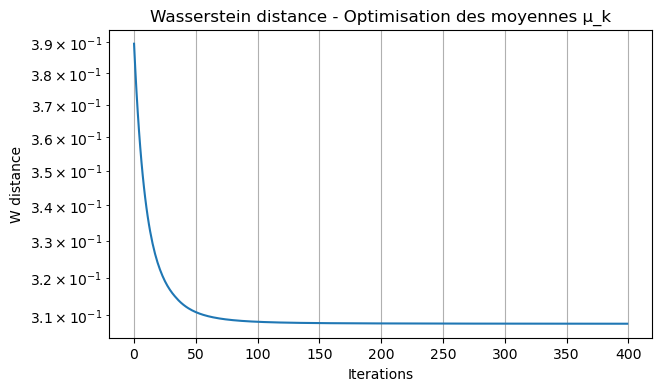

COMPARAISON DES MOYENNES
Vraies moyennes       :
 [[0 0]
 [3 3]
 [0 4]
 [4 0]]
Moyennes EM           :
 [[ 3.93510096  0.0047392 ]
 [ 3.03340326  2.9926775 ]
 [-0.0070519  -0.00394784]
 [-0.00436662  3.82942067]]
Moyennes OT           :
 [[ 3.47141975 -0.1631912 ]
 [ 2.81746949  2.85783397]
 [-0.08094478 -0.09552061]
 [-0.0151449   3.89087034]]



In [85]:
# Génération d'un bruit ε ~ N(0,1) pour chaque point
eps = torch.randn(N, D, dtype=torch.float64)

# Paramètre à optimiser : les moyennes des clusters
mu = torch.tensor(em_means.copy(), dtype=torch.float64, requires_grad=True)

# Labels des points indiquant leur cluster
ls = torch.tensor(labels_source, dtype=torch.long)

# Poids des clusters fixés (issus de l'optimisation OT)
we_tensor = torch.tensor(we, dtype=torch.float64)

# Points de la distribution cible
X_torch = torch.tensor(X, dtype=torch.float64)

# Poids des points source et cible (fixés)
a_opt = torch.mv(H2, we_tensor).detach()
b_fixed = torch.mv(J2, w_fixed)

# Écart-type des clusters (issu de EM)
em_stds = np.sqrt(np.array([np.diag(em_covs[k]) for k in range(K)]))
sigma = torch.tensor(em_stds.copy(), dtype=torch.float64)

# Hyperparamètres pour l'optimisation
eta0_mu = 1e-1        # taux d'apprentissage initial
IterMax_mu = 400      # nombre d'itérations
losses_mu = []        # stockage de la loss


# Fonction de loss : distance de Wasserstein
def get_loss_mu(mu):
    XS_mu = mu[ls] + eps * sigma[ls]  # Reparametrization Trick
    M_mu = ot.dist(XS_mu, X_torch)    # recalcul de la matrice de distances
    return ot.emd2(a_opt, b_fixed, M_mu)

# Boucle d'optimisation
for epoch in range(IterMax_mu):
    eta = eta0_mu / (1 + 0.02 * epoch)  # taux d'apprentissage décroissant
    loss = get_loss_mu(mu)
    losses_mu.append(float(loss))
    loss.backward()  # calcul du gradient
    with torch.no_grad():
        mu -= eta * mu.grad  # mise à jour des moyennes
        mu.grad.zero_()      # remise à zéro du gradient

# Conversion des moyennes optimisées en numpy
mu_opt = mu.detach().numpy()


# Affichage de l'évolution de la loss
pl.figure(figsize=(7, 4))
pl.semilogy(losses_mu)
pl.grid()
pl.title('Wasserstein distance - Optimisation des moyennes µ_k')
pl.xlabel('Iterations')
pl.ylabel('W distance')
pl.show()


# Comparaison des moyennes
print('COMPARAISON DES MOYENNES')
print('Vraies moyennes       :\n', means)
print('Moyennes EM           :\n', em_means)
print('Moyennes OT           :\n', mu_opt)
print()

## Approche Monte Carlo : 
Jusqu'à présent, l'optimisation se fait sur un seul tirage de eps.
On peut répéter l'échantillonnage de eps plusieurs fois à chaque itération pour  obtenir une meilleure estimation du gradient.

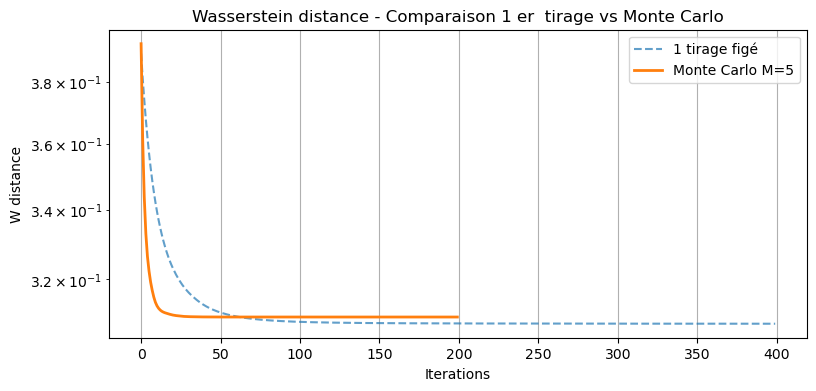

COMPARAISON DES MOYENNES
Vraies moyennes        :
 [[0 0]
 [3 3]
 [0 4]
 [4 0]]
Moyennes EM            :
 [[ 3.93510096  0.0047392 ]
 [ 3.03340326  2.9926775 ]
 [-0.0070519  -0.00394784]
 [-0.00436662  3.82942067]]
Moyennes OT (1 tirage) :
 [[ 3.47141975 -0.1631912 ]
 [ 2.81746949  2.85783397]
 [-0.08094478 -0.09552061]
 [-0.0151449   3.89087034]]
Moyennes OT (MC)       :
 [[ 3.32472824 -0.13772228]
 [ 2.98987747  2.85133125]
 [-0.1729303  -0.00570812]
 [-0.04289818  3.95685977]]


In [86]:
# Approche Monte-Carlo 

M_mc = 5 # nombre de realisation de bruit epsilon 
eps_list = [torch.randn(N, D, dtype=torch.float64) for _ in range(M_mc)]

# initialisation des parametres a optimiser et des tenseurs fixes 
mu_mc = torch.tensor(em_means.copy(), dtype=torch.float64, requires_grad=True)
ls = torch.tensor(labels_source, dtype=torch.long)
we_tensor = torch.tensor(we, dtype=torch.float64)
X_torch = torch.tensor(X, dtype=torch.float64)
a_opt = torch.mv(H2, we_tensor).detach()
b_fixed = torch.mv(J2, w_fixed)
em_stds = np.sqrt(np.array([np.diag(em_covs[k]) for k in range(K)]))
sigma = torch.tensor(em_stds.copy(), dtype=torch.float64)

#hyperparametres 
eta0_mu = 5e-1
IterMax_mu = 200
losses_mc = []


# Loss = moyenne des distance de wassertein sur les M realisation de epsilon 
def get_loss_mc(mu):
    total_loss = 0
    for eps in eps_list:                          # pour chaque realisation epsilon 
        XS_mu = mu[ls] + eps * sigma[ls]          # reparameterization trick
        M_mu = ot.dist(XS_mu, X_torch)            # matrice de coût
        total_loss += ot.emd2(a_opt, b_fixed, M_mu)
    return total_loss / M_mc                       # moyenne sur M tirages


# Boucle d'optimisation
for epoch in range(IterMax_mu):
    eta = eta0_mu / (1 + 0.002 * epoch)
    loss = get_loss_mc(mu_mc)
    losses_mc.append(float(loss))
    loss.backward()
    with torch.no_grad():
        mu_mc -= eta * mu_mc.grad
        mu_mc.grad.zero_()

mu_opt_mc = mu_mc.detach().numpy()


# Affichage
pl.figure(figsize=(9, 4))
pl.semilogy(losses_mu, label='1 tirage figé', linestyle='--', alpha=0.7)
pl.semilogy(losses_mc, label=f'Monte Carlo M={M_mc}', linewidth=2)
pl.grid()
pl.legend()
pl.title('Wasserstein distance - Comparaison 1 er  tirage vs Monte Carlo')
pl.xlabel('Iterations')
pl.ylabel('W distance')
pl.show()

# Comparaison
print('COMPARAISON DES MOYENNES')
print('Vraies moyennes        :\n', means)
print('Moyennes EM            :\n', em_means)
print('Moyennes OT (1 tirage) :\n', mu_opt)
print('Moyennes OT (MC)       :\n', mu_opt_mc)

## Optimisation par la méthode de la grille

On crée une **grille 2D** pour évaluer les distributions source et cible, de manière à **calculer la densité de la GMM dans chaque case** de la grille.  
Cette approche rend le calcul déterministe, contrairement à l’échantillonnage Monte Carlo.  

torch.Size([400, 2])


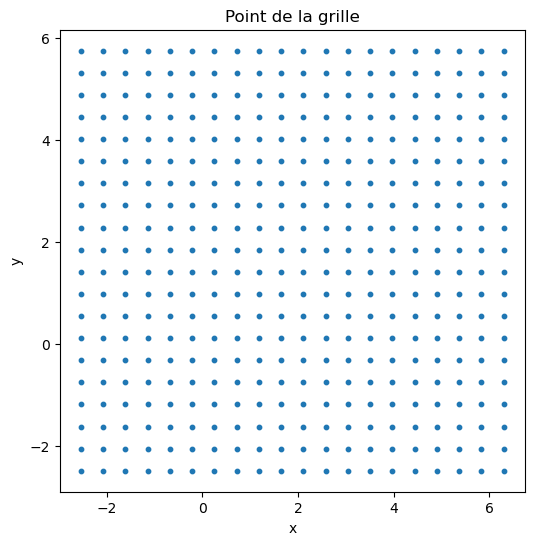

In [87]:
# Methode de la grille : la grille va nous servir pour evaluer les deux distributions 
# on commence par fixer la taille de la grille 
Grid_size=20 # donc on aura  20^2 = 400 case

# on definit les bornes de la grille en ajoutant une marge (=1)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# on cree des points reguliers sur chaque axe 
xs = torch.linspace(x_min, x_max, Grid_size, dtype=torch.float64)
ys = torch.linspace(y_min, y_max, Grid_size, dtype=torch.float64)

# construction de la grille (tous les couple (x,y))
grid_x, grid_y = torch.meshgrid(xs, ys, indexing='ij')
grid = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

#verification de la taille de la grille 
print(grid.shape)

#visualisation 

plt.figure(figsize=(6,6))
plt.scatter(grid_x, grid_y, s=10)  # chaque point de la grille
plt.xlabel('x')
plt.ylabel('y')
plt.title('Point de la grille')
plt.show()


In [88]:
# Fonction pour calculer la densité en  chaque point  de la grille 
def get_densite(mu,covs,w,grid):
    size = grid.shape[0] # nombre de points dans la grille
    densite = torch.zeros(size,dtype=torch.float64)
    
    for k in range(K): # pour chaque cluster on calcule la densité de la gmm de ce cluster 
        #parametres de cluster k 
        mu_k = mu[k]           # moyenne : vecteur de taille D
        cov_k = covs[k]        # covariance : matrice D*D
        w_k = w[k]             # poids : vecteur de taille K 
        
        det_cov= torch.det(cov_k) # le determinant de la covariance 
        cov_inv= torch.inverse(cov_k) # l'inverse de la covariance 
        
        c = 1.0 / (2 * torch.pi * torch.sqrt(det_cov))
        diff = grid - mu_k
        terme = (diff @ cov_inv * diff).sum(dim=1)
        densite += w[k] * c * torch.exp(-0.5*terme)
    return densite
        
        
        

In [89]:
# convertir les paramètres en tenseurs torch
mu_source  = torch.tensor(em_means.copy(),dtype=torch.float64)
cov_source = torch.tensor(em_covs.copy(),    dtype=torch.float64)
w_source   = torch.tensor(em_weights.copy(), dtype=torch.float64)

mu_cible   = torch.tensor(means.copy(),   dtype=torch.float64)
cov_cible  = torch.tensor(covs.copy(),    dtype=torch.float64)
w_cible    = torch.tensor(weights.copy(), dtype=torch.float64)

# Calcul de la densité sur la grille pour les deux distributions
p = get_densite(mu_source, cov_source, w_source, grid)
q = get_densite(mu_cible,  cov_cible,  w_cible,  grid)

print(p.shape)  
print(q.shape)  


torch.Size([400])
torch.Size([400])


In [90]:
# on normalise les tenseurs (necessaire pour le calcul de la distance de wassertein : doivent avoir la meme masse )
p = p / p.sum()
q = q / q.sum()


In [91]:
#construction de la matrice cout entre tous les points de la grille 
M = ot.dist(grid, grid)
print(M.shape)  


torch.Size([400, 400])


## Optimisation des poids – Méthode de la grille : 
on fixe dans cette partie les moyennes et les covariance 

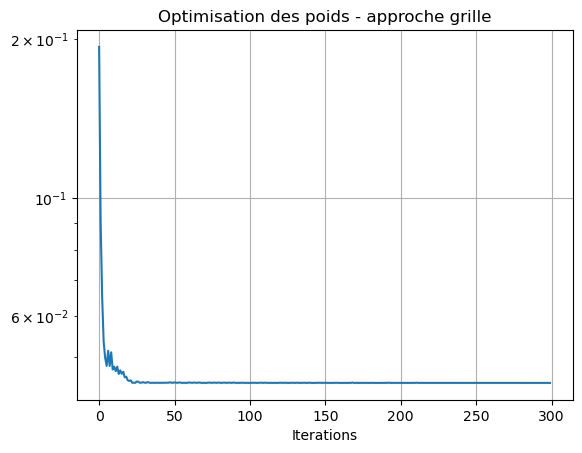

Vrais poids    : [0.4 0.3 0.1 0.2]
Poids EM       : [0.18061721 0.35020985 0.3747931  0.09437985]
Poids optimisés: [0.20720635 0.2895907  0.39816837 0.10503458]
methode de Remy Flamary: [0.23174228 0.33650863 0.33842944 0.09331965]


In [92]:
# paramètre à optimiser : les poids de la gmm source 
w_opt = torch.tensor(em_weights.copy(), dtype=torch.float64, requires_grad=True)

# q est fixe : on le  calcule une seule fois : la densité de la distribution cible 
q = get_densite(mu_cible, cov_cible, w_cible, grid)
q = q / q.sum() # normalisation 

# hyperparamètres
eta0 = 1e-2
IterMax = 300
losses_grid = []

for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
    
    # calculer p à partir de w_opt (mu et cov fixés)
    p = get_densite(mu_source, cov_source, w_opt, grid)
    p = p / p.sum()
    
    # loss = distance de Wasserstein
    loss = ot.emd2(p, q, M)
    losses_grid.append(float(loss))
    
    loss.backward()
    
    with torch.no_grad():
        w_opt -= eta * w_opt.grad # mise a jour avec la descente de gradient 
        w_opt[:] = ot.utils.proj_simplex(w_opt) # projection sur le simplexe pour assurer que les poids sont postids et somment a 1 
        w_opt.grad.zero_() # remettre le gradient a 0 

# affichage
pl.semilogy(losses_grid)
pl.grid()
pl.title('Optimisation des poids - approche grille')
pl.xlabel('Iterations')
pl.show()

print('Vrais poids    :', weights)
print('Poids EM       :', em_weights)
print('Poids optimisés:', w_opt.detach().numpy())
print('methode de Remy Flamary:', we)

## Optimisation des moyennes – Méthode de la grille

Dans cette partie, on fixe :

- les poids déjà estimés,
- les matrices de covariance.

On optimise uniquement les moyennes des clusters.

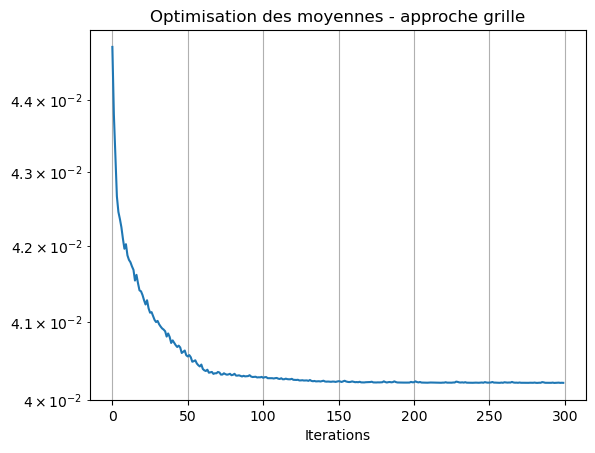

Vraies moyennes : [[0 0]
 [3 3]
 [0 4]
 [4 0]]
Moyennes EM     : [[ 3.93510096  0.0047392 ]
 [ 3.03340326  2.9926775 ]
 [-0.0070519  -0.00394784]
 [-0.00436662  3.82942067]]
Moyennes OT     : [[ 3.94553029e+00  1.78497341e-02]
 [ 3.02137524e+00  3.00726517e+00]
 [-7.82293077e-03  2.57762024e-03]
 [ 6.59443501e-02  3.92899979e+00]]


In [93]:
# paramètre à optimiser : les moyennes
mu_opt = torch.tensor(em_means.copy(), dtype=torch.float64, requires_grad=True)

# w et cov  sont fixés 
w_fixe = torch.tensor(w_opt.detach().numpy().copy(), dtype=torch.float64)
cov_fixe = torch.tensor(em_covs.copy(), dtype=torch.float64)

# q fixe : la densité de la distribution cible 
q = get_densite(mu_cible, cov_cible, w_cible, grid)
q = q / q.sum() # normalisation 

# hyperparamètres
eta0 = 1e-1
IterMax = 300
losses_mu_grid = []

for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
    # p calculé avec mu_opt qui change (la densité de la distribution source)
    p = get_densite(mu_opt, cov_fixe, w_fixe, grid)
    p = p / p.sum()
    loss = ot.emd2(p, q, M)
    losses_mu_grid.append(float(loss))
    loss.backward()
    with torch.no_grad():
        mu_opt -= eta * mu_opt.grad
        mu_opt.grad.zero_()

# affichage de la loss
pl.semilogy(losses_mu_grid)
pl.grid()
pl.title('Optimisation des moyennes - approche grille')
pl.xlabel('Iterations')
pl.show()

print('Vraies moyennes :', means)
print('Moyennes EM     :', em_means)
print('Moyennes OT     :', mu_opt.detach().numpy())

## Optimisation des covariances – Méthode de la grille

- On fixe les poids et les moyennes déjà optimisés.  
- On optimise les covariances via leur factorisation de Cholesky L, pour garantir qu’elles restent valides (symetrique).  
- On calcule la densité de la source sur la grille et la normalise.  
- On mesure la distance de Wasserstein avec la cible.  
- On met à jour L par descente de gradient et on reconstruit Σ = L @ Lᵀ.  


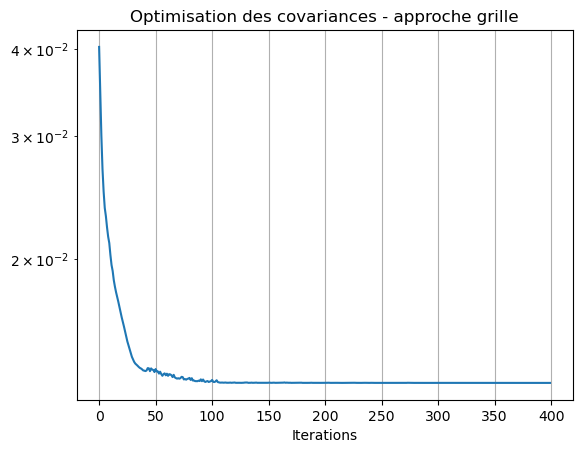

Vraies covs :
 [[[0.4 0. ]
  [0.  0.4]]

 [[0.4 0. ]
  [0.  0.4]]

 [[0.4 0. ]
  [0.  0.4]]

 [[0.4 0. ]
  [0.  0.4]]]
Covs EM     :
 [[[ 0.49258385 -0.17113427]
  [-0.17113427  0.53778459]]

 [[ 0.34331687 -0.00555775]
  [-0.00555775  0.32112912]]

 [[ 0.41334476 -0.03546316]
  [-0.03546316  0.34151248]]

 [[ 0.48186171 -0.11223665]
  [-0.11223665  0.35641774]]]
Covs OT     :
 [[[ 0.44457504 -0.0079945 ]
  [-0.0079945   0.41417396]]

 [[ 0.38099055  0.00811862]
  [ 0.00811862  0.38626154]]

 [[ 0.3946972   0.00090043]
  [ 0.00090043  0.40056897]]

 [[ 0.47056283 -0.03575283]
  [-0.03575283  0.40533172]]]


In [94]:
# initialiser L à partir des covariances EM (factorisation de Cholesky)
L_init = torch.linalg.cholesky(torch.tensor(em_covs.copy(), dtype=torch.float64))
L_opt = L_init.clone().requires_grad_(True)

# On fixe les poids et les moyennes optimisés précédemment
w_fixe  = torch.tensor(w_opt.detach().numpy().copy(), dtype=torch.float64)
mu_fixe = mu_opt.detach().clone()

# q fixe : densité de la distribution cible sur la grille
q = get_densite(mu_cible, cov_cible, w_cible, grid)
q = q / q.sum() #normalisation 

# hyperparamètres
eta0 = 1e-1
IterMax = 400
losses_cov_grid = []

for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
    # reconstruire Σ = L @ Lᵀ
    cov_opt = L_opt @ L_opt.transpose(-1, -2)
    # p calculé avec cov_opt qui change
    p = get_densite(mu_fixe, cov_opt, w_fixe, grid)
    p = p / p.sum()
    loss = ot.emd2(p, q, M)
    losses_cov_grid.append(float(loss))
    loss.backward()
    with torch.no_grad():
        L_opt -= eta * L_opt.grad
        L_opt.grad.zero_()

# reconstruire les covariances finales
cov_final = (L_opt @ L_opt.transpose(-1, -2)).detach().numpy()

# affichage
pl.semilogy(losses_cov_grid)
pl.grid()
pl.title('Optimisation des covariances - approche grille')
pl.xlabel('Iterations')
pl.show()

print('Vraies covs :\n', covs)
print('Covs EM     :\n', em_covs)
print('Covs OT     :\n', cov_final)

## 2ᵉ cas : méthode de la grille pour D=3

Dans cette partie, on fixe la dimension à **D = 3** et on optimise les paramètres (**poids, moyennes et covariances**) avec la **méthode de la grille**.  

On reprend les mêmes fonctions que précédemment pour :  
- calculer la densité sur la grille (`get_densite`)  
- construire la grille 3D  
- calculer la matrice de coût pour la distance de Wasserstein  

La logique reste identique à celle du cas 2D, mais adaptée à 3 dimensions.  
La grille sert à évaluer la densité des distributions à des points réguliers pour calculer la loss.  


## Génération de la distribution cible (D=3)

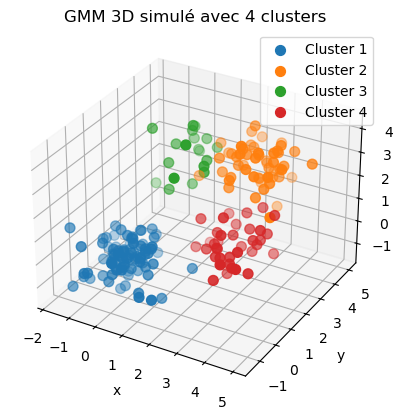

In [95]:

K = 4  # nombre de clusters
N = 200  # nombre de points total
D = 3  # la dimension des données 
weights = np.array([0.4, 0.3, 0.1, 0.2])
means = np.array([[0, 0, 0], [3, 3, 3], [0, 4, 2], [4, 0, 2]]) 
covs = np.array([np.eye(3) * 0.4 for _ in range(K)])  #  matrices 3×3

# Tirage des clusters
Z = rng.choice(range(K), size=N, p=weights)

# Génération des points
X = np.zeros((N, D))
for i in range(N):
    k = Z[i]
    X[i] = np.random.multivariate_normal(means[k], covs[k])

# Visualisation en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for k in range(K):
    ax.scatter(X[Z==k, 0], X[Z==k, 1], X[Z==k, 2], s=50, label=f'Cluster {k+1}')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("GMM 3D simulé avec 4 clusters")
ax.legend()
plt.show()

## Distribution source via l'algorithme EM

C:\Users\lorie\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Poids estimés : [0.43973185 0.36600411 0.10903071 0.08523332]
Moyennes estimées : [[-1.60766168e-03 -3.78687042e-02 -6.07805578e-02]
 [ 2.19638167e+00  3.31622492e+00  2.84588159e+00]
 [ 3.97817547e+00  5.05369281e-01  1.87503937e+00]
 [ 3.91444236e+00 -7.28040756e-01  1.98878783e+00]]
Covariances estimées : [[[ 0.43246589  0.00822104  0.0179814 ]
  [ 0.00822104  0.35571401  0.0246674 ]
  [ 0.0179814   0.0246674   0.3160502 ]]

 [[ 2.3653532  -0.61666175  0.71633128]
  [-0.61666175  0.61808385 -0.23172121]
  [ 0.71633128 -0.23172121  0.65629461]]

 [[ 0.48859518 -0.00317386  0.23318781]
  [-0.00317386  0.22130151  0.05343833]
  [ 0.23318781  0.05343833  0.43314228]]

 [[ 0.29168405 -0.16221206 -0.07336608]
  [-0.16221206  0.17186927  0.07742364]
  [-0.07336608  0.07742364  0.19216622]]]


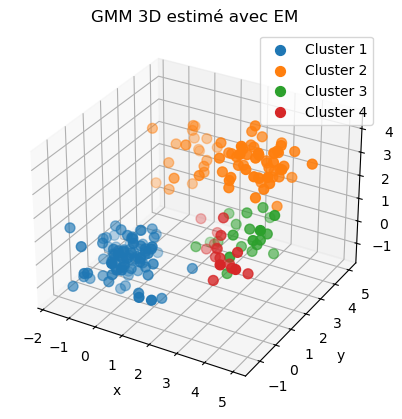

In [96]:

gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=0)
gmm.fit(X)

# Labels prévus par l'algorithme EM
labels = gmm.predict(X)

# paramètres estimés
em_weights = gmm.weights_
em_means = gmm.means_
em_covs = gmm.covariances_


print("Poids estimés :", em_weights)
print("Moyennes estimées :", em_means)
print("Covariances estimées :", em_covs)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for k in range(K):
    ax.scatter(X[labels==k, 0], X[labels==k, 1], X[labels==k, 2], 
               s=50, label=f'Cluster {k+1}')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("GMM 3D estimé avec EM")
ax.legend()
plt.show()


## Création de la grille

In [97]:
Grid_size = 9 #

# bornes de la grille
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
z_min, z_max = X[:, 2].min() - 1, X[:, 2].max() + 1 

# points réguliers sur chaque axe
xs = torch.linspace(x_min, x_max, Grid_size, dtype=torch.float64)
ys = torch.linspace(y_min, y_max, Grid_size, dtype=torch.float64)
zs = torch.linspace(z_min, z_max, Grid_size, dtype=torch.float64)  

# construction de la grille 3D
grid_x, grid_y, grid_z = torch.meshgrid(xs, ys, zs, indexing='ij') 

# aplatir en liste de points 
grid = torch.stack([grid_x.flatten(), grid_y.flatten(), grid_z.flatten()], dim=1)
print(grid.shape)  

torch.Size([729, 3])


## Fonction pour calculer la densité en chaque point de la grille

In [98]:
def get_densite(mu, covs, w, grid):
    size = grid.shape[0]
    D = grid.shape[1]  
    densite = torch.zeros(size, dtype=torch.float64)
    
    for k in range(K):
        mu_k = mu[k]
        cov_k = covs[k]
        
        det_cov = torch.det(cov_k)
        cov_inv = torch.inverse(cov_k)
        
        c = 1.0 / ((2 * torch.pi) ** (D / 2) * torch.sqrt(det_cov))
        
        diff = grid - mu_k
        terme = (diff @ cov_inv * diff).sum(dim=1)
        densite += w[k] * c * torch.exp(-0.5 * terme)
    
    return densite

In [99]:
# construction de la matrice cout
M = ot.dist(grid, grid)
print(M.shape) 

torch.Size([729, 729])


In [100]:
# convertir les paramètres en tenseurs torch
mu_source  = torch.tensor(em_means.copy(),dtype=torch.float64)
cov_source = torch.tensor(em_covs.copy(),    dtype=torch.float64)
w_source   = torch.tensor(em_weights.copy(), dtype=torch.float64)

mu_cible   = torch.tensor(means.copy(),   dtype=torch.float64)
cov_cible  = torch.tensor(covs.copy(),    dtype=torch.float64)
w_cible    = torch.tensor(weights.copy(), dtype=torch.float64)

# remplir les deux vecteurs
p = get_densite(mu_source, cov_source, w_source, grid)
q = get_densite(mu_cible,  cov_cible,  w_cible,  grid)

print(p.shape)  # (2500,)
print(q.shape)  # (2500,)


torch.Size([729])
torch.Size([729])


## Optimisation des poids 

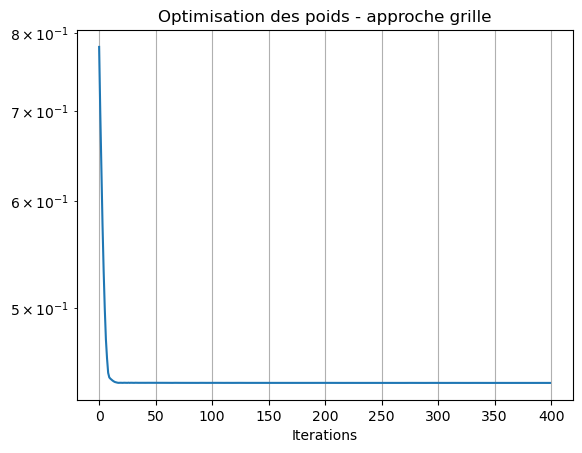

Vrais poids    : [0.4 0.3 0.1 0.2]
Poids EM       : [0.43973185 0.36600411 0.10903071 0.08523332]
Poids optimisés: [0.39469449 0.39335077 0.11881648 0.09313825]


In [101]:
# paramètre à optimiser : les poids
w_opt = torch.tensor(em_weights.copy(), dtype=torch.float64, requires_grad=True)

# q est fixe : on le  calcule une seule fois
q = get_densite(mu_cible, cov_cible, w_cible, grid)
q = q / q.sum() # normalisation 

# hyperparamètres
eta0 = 1e-3
IterMax = 400
losses_grid = []

for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
    
    # calculer p à partir de w_opt (mu et cov fixés)
    p = get_densite(mu_source, cov_source, w_opt, grid)
    p = p / p.sum()
    
    # loss = distance de Wasserstein
    loss = ot.emd2(p, q, M)
    losses_grid.append(float(loss))
    
    loss.backward()
    
    with torch.no_grad():
        w_opt -= eta * w_opt.grad # mise a jour avec la descente de gradient 
        w_opt[:] = ot.utils.proj_simplex(w_opt) # projection sur le simplexe pour assurer que les poids sont postids et somment a 1 
        w_opt.grad.zero_() # remettre le gradient a 0 

# affichage
pl.semilogy(losses_grid)
pl.grid()
pl.title('Optimisation des poids - approche grille')
pl.xlabel('Iterations')
pl.show()

print('Vrais poids    :', weights)
print('Poids EM       :', em_weights)
print('Poids optimisés:', w_opt.detach().numpy())

## Optimisation des moyennes

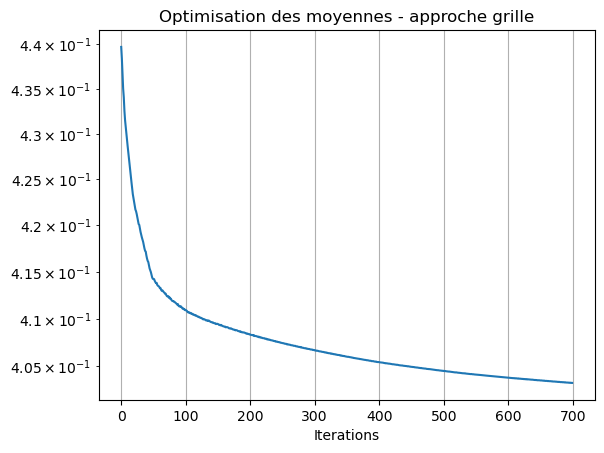

Vraies moyennes : [[0 0 0]
 [3 3 3]
 [0 4 2]
 [4 0 2]]
Moyennes EM     : [[-1.60766168e-03 -3.78687042e-02 -6.07805578e-02]
 [ 2.19638167e+00  3.31622492e+00  2.84588159e+00]
 [ 3.97817547e+00  5.05369281e-01  1.87503937e+00]
 [ 3.91444236e+00 -7.28040756e-01  1.98878783e+00]]
Moyennes OT     : [[ 5.93826606e-05  6.29421108e-03 -5.74260933e-04]
 [ 2.20224964e+00  3.29881556e+00  2.80286265e+00]
 [ 3.98979390e+00  4.08587873e-01  1.87150798e+00]
 [ 3.84419525e+00 -6.77937215e-01  1.96665522e+00]]


In [102]:
# paramètre à optimiser : les moyennes
mu_opt = torch.tensor(em_means.copy(), dtype=torch.float64, requires_grad=True)

# w et cov fixés aux valeurs trouvées précédemment
w_fixe = torch.tensor(w_opt.detach().numpy().copy(), dtype=torch.float64)
cov_fixe = torch.tensor(em_covs.copy(), dtype=torch.float64)

# q fixe
q = get_densite(mu_cible, cov_cible, w_cible, grid)
q = q / q.sum()

# hyperparamètres
eta0 = 1e-2
IterMax = 700
losses_mu_grid = []

for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
    
    # p calculé avec mu_opt qui change
    p = get_densite(mu_opt, cov_fixe, w_fixe, grid)
    p = p / p.sum()
    
    loss = loss = ot.emd2(p, q, M)
    losses_mu_grid.append(float(loss))
    
    loss.backward()
    
    with torch.no_grad():
        mu_opt -= eta * mu_opt.grad
        mu_opt.grad.zero_()

# affichage
pl.semilogy(losses_mu_grid)
pl.grid()
pl.title('Optimisation des moyennes - approche grille')
pl.xlabel('Iterations')
pl.show()

print('Vraies moyennes :', means)
print('Moyennes EM     :', em_means)
print('Moyennes OT     :', mu_opt.detach().numpy())

## Optimisation des covariances: 

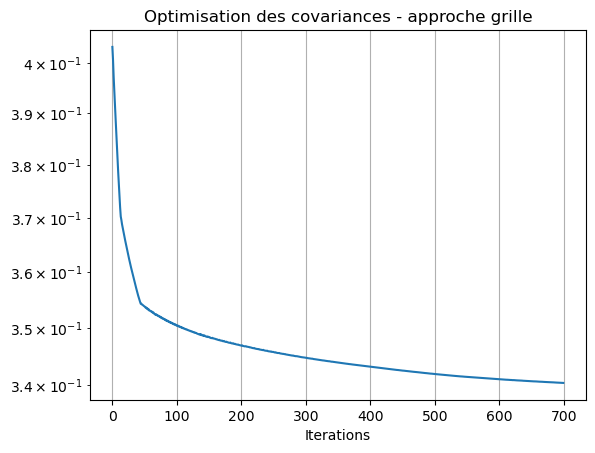

Vraies covs :
 [[[0.4 0.  0. ]
  [0.  0.4 0. ]
  [0.  0.  0.4]]

 [[0.4 0.  0. ]
  [0.  0.4 0. ]
  [0.  0.  0.4]]

 [[0.4 0.  0. ]
  [0.  0.4 0. ]
  [0.  0.  0.4]]

 [[0.4 0.  0. ]
  [0.  0.4 0. ]
  [0.  0.  0.4]]]
Covs EM     :
 [[[ 0.43246589  0.00822104  0.0179814 ]
  [ 0.00822104  0.35571401  0.0246674 ]
  [ 0.0179814   0.0246674   0.3160502 ]]

 [[ 2.3653532  -0.61666175  0.71633128]
  [-0.61666175  0.61808385 -0.23172121]
  [ 0.71633128 -0.23172121  0.65629461]]

 [[ 0.48859518 -0.00317386  0.23318781]
  [-0.00317386  0.22130151  0.05343833]
  [ 0.23318781  0.05343833  0.43314228]]

 [[ 0.29168405 -0.16221206 -0.07336608]
  [-0.16221206  0.17186927  0.07742364]
  [-0.07336608  0.07742364  0.19216622]]]
Covs OT     :
 [[[ 4.00026968e-01  1.36966778e-03 -2.93608826e-05]
  [ 1.36966778e-03  3.96806634e-01 -4.62631593e-04]
  [-2.93608826e-05 -4.62631593e-04  3.99596274e-01]]

 [[ 2.18014650e+00 -6.44934885e-01  6.49201052e-01]
  [-6.44934885e-01  6.05344300e-01 -2.20509664e-01]
  [ 6

In [103]:
# initialiser L à partir des covariances EM
L_init = torch.linalg.cholesky(torch.tensor(em_covs.copy(), dtype=torch.float64))
L_opt = L_init.clone().requires_grad_(True)

# w et mu fixés
w_fixe  = torch.tensor(w_opt.detach().numpy().copy(), dtype=torch.float64)
mu_fixe = mu_opt.detach().clone()

# q fixe
q = get_densite(mu_cible, cov_cible, w_cible, grid)
q = q / q.sum()

# hyperparamètres
eta0 = 1e-2
IterMax = 700
losses_cov_grid = []

for epoch in range(IterMax):
    eta = eta0 / (1 + 0.02 * epoch)
    
    # reconstruire Σ = L @ Lᵀ
    cov_opt = L_opt @ L_opt.transpose(-1, -2)
    
    # p calculé avec cov_opt qui change
    p = get_densite(mu_fixe, cov_opt, w_fixe, grid)
    p = p / p.sum()
    
    loss = ot.emd2(p, q, M)
    losses_cov_grid.append(float(loss))
    
    loss.backward()
    
    with torch.no_grad():
        L_opt -= eta * L_opt.grad
        L_opt.grad.zero_()

# reconstruire les covariances finales
cov_final = (L_opt @ L_opt.transpose(-1, -2)).detach().numpy()

# affichage
pl.semilogy(losses_cov_grid)
pl.grid()
pl.title('Optimisation des covariances - approche grille')
pl.xlabel('Iterations')
pl.show()

print('Vraies covs :\n', covs)
print('Covs EM     :\n', em_covs)
print('Covs OT     :\n', cov_final)

## Partie 2 : optimisation des poids uniquement

Dans cette section, nous fixons les positions ($\mu$) et les formes ($\Sigma$) obtenues par l'EM. L'objectif est d'isoler l'influence des poids sur la distance de Wasserstein. Nous résolvons le problème du Wasserstein Unmixing grâce à la méthode  du softmax

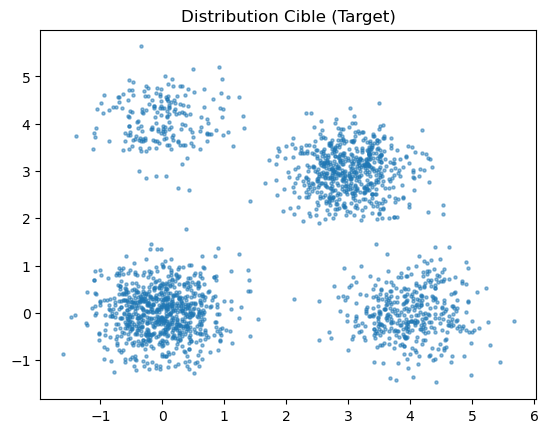

In [104]:
n_points = 2000
vrais_poids = np.array([0.4, 0.3, 0.1, 0.2])
vraies_moyennes = np.array([[0, 0], [3, 3], [0, 4], [4, 0]])

X_list = []
for i in range(len(vrais_poids)):
    n_k = int(n_points * vrais_poids[i])
    # On génère des points autour des moyennes avec un écart-type de 0.5
    points = np.random.normal(loc=vraies_moyennes[i], scale=0.5, size=(n_k, 2))
    X_list.append(points)

X = np.vstack(X_list)

plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.5)
plt.title("Distribution Cible (Target)")
plt.show()

In [105]:
# On demande à l'EM de trouver 4 groupes
gmm = GaussianMixture(n_components=4, random_state=42).fit(X)

# On récupère les valeurs pour utiliser PyTorch
init_poids = torch.tensor(gmm.weights_, dtype=torch.float32)
init_mu = torch.tensor(gmm.means_, dtype=torch.float32)

print("Poids trouvés par EM au départ :", init_poids.numpy())

Poids trouvés par EM au départ : [0.40004504 0.20029125 0.29969573 0.09996799]


C:\Users\lorie\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


In [106]:
#à changer, mais mettre une taille + petite au début pour tester
taille_grille = 40
# l'étendue de la zone de calcul
axe = torch.linspace(-2, 6, taille_grille)
grid_x, grid_y = torch.meshgrid(axe, axe, indexing='ij')
# On aplatit pour avoir une liste de 1600 points 
points_grille = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

# Création de l'image de la cible (Histogramme)
H, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins=taille_grille, range=[[-2, 6], [-2, 6]])
# On normalise pour que la somme des pixels = 1
p_target = torch.tensor(H.flatten() / H.sum(), dtype=torch.float32)

In [107]:
 #distance euclidienne au carré (par défaut dans la bibli ot) entre le pixel i et le pixel j
M = ot.dist(points_grille, points_grille)
M = M / M.max() # Normalisation pour éviter des valeurs trop grandes (stabilité)

M_torch = torch.tensor(M, dtype=torch.float32)

C:\Users\lorie\AppData\Local\Temp\ipykernel_29228\2449611239.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M_torch = torch.tensor(M, dtype=torch.float32)


C:\Users\lorie\AppData\Local\Temp\ipykernel_29228\1273956823.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  poids_logits = torch.tensor(init_poids, requires_grad=True)


Itération 0, Distance de Wasserstein: 0.008086
Itération 20, Distance de Wasserstein: 0.003467
Itération 40, Distance de Wasserstein: 0.001768
Itération 60, Distance de Wasserstein: 0.001151
Itération 80, Distance de Wasserstein: 0.000752
Itération 100, Distance de Wasserstein: 0.000493
Itération 120, Distance de Wasserstein: 0.000337
Itération 140, Distance de Wasserstein: 0.000255
Itération 160, Distance de Wasserstein: 0.000216
Itération 180, Distance de Wasserstein: 0.000199
Itération 200, Distance de Wasserstein: 0.000192
Itération 220, Distance de Wasserstein: 0.000191
Itération 240, Distance de Wasserstein: 0.000191
Itération 260, Distance de Wasserstein: 0.000191
Itération 280, Distance de Wasserstein: 0.000190
Itération 300, Distance de Wasserstein: 0.000191
Itération 320, Distance de Wasserstein: 0.000191
Itération 340, Distance de Wasserstein: 0.000190
Itération 360, Distance de Wasserstein: 0.000191
Itération 380, Distance de Wasserstein: 0.000190
Itération 400, Distance de

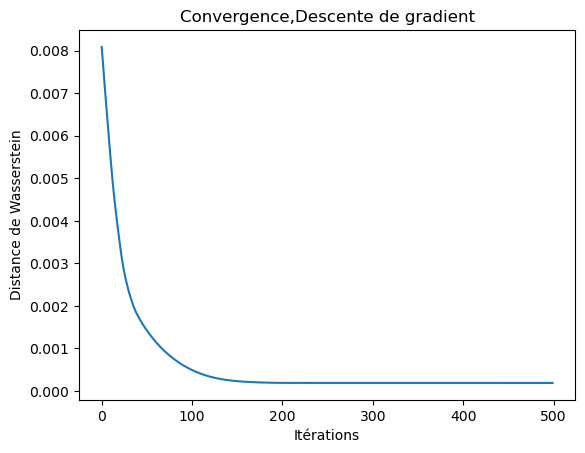

In [108]:
 n_iter = 500
learning_rate = 1.0  # eta
losses = []

# On repart des poids de l'EM
# On utilise requires_grad=True pour que PyTorch calcule le gradient pour nous
poids_logits = torch.tensor(init_poids, requires_grad=True)

for i in range(n_iter):
    #  Calcul de la densité du modèle sur la grille
    # On transforme les logits en probabilités (Somme = 1)
    w = torch.softmax(poids_logits, dim=0)
    p_model = torch.zeros(taille_grille * taille_grille)
    
    for k in range(4):
        dist = torch.sum((points_grille - init_mu[k])**2, dim=1)
        gauss = torch.exp(-dist / 0.5)
        p_model += w[k] * gauss
    
    p_model = p_model / p_model.sum()

    #  Calcul de la perte (Wasserstein / EMD)
    loss = ot.emd2(p_model, p_target, M_torch)
    losses.append(loss.item())

    # Calcul du Gradient 
    loss.backward()

    # on effectue la descente de gradient manuelle
    # on désactive temporairement le suivi pour ne pas enregistrer la mise à jour elle-même
    with torch.no_grad():
        # règle de mise à jour 
        poids_logits -= learning_rate * poids_logits.grad
        
        # on remet le gradient à zéro pour l'itération suivante
        poids_logits.grad.zero_()

    if i % 20 == 0:
        print(f"Itération {i}, Distance de Wasserstein: {loss.item():.6f}")

# Affichage 
plt.plot(losses)
plt.title("Convergence,Descente de gradient")
plt.xlabel("Itérations")
plt.ylabel("Distance de Wasserstein")
plt.show()

## Partie 3 : optimisation paramétrique complète

Dans cette dernière étape, on ne se contente plus de régler le volume de nos 4 sources (les poids). On va beaucoup plus loin en laissant nos Gaussiennes se déplacer et changer de forme librement pour qu'elles collent au mieux à la réalité. 

On commence d'abord par générer les données, qui vont représenter la vérité du terrain

In [115]:
# on définit le nombre total de points  à générer
n_points = 2000 
# on définit les proportions réelles de chaque groupe, le poids
vrais_poids = np.array([0.4, 0.3, 0.1, 0.2]) 
# On définit les coordonnées (x,y) du centre de chaque groupe 
vraies_moyennes = np.array([[0, 0], [3, 3], [0, 4], [4, 0]]) 

#liste vide qui contiendra les poids
X_list = []
# on boucle sur les 4 groupes pour générer les points un par un
for i in range(len(vrais_poids)):
    # on calcule combien de points vont dans ce groupe exact
    n_k = int(n_points * vrais_poids[i]) 
    
    #ono génère des points normalement distribués autour de la moyenne avec un écart-type de 0.5 
    points = np.random.normal(loc=vraies_moyennes[i], scale=0.5, size=(n_k, 2))
    X_list.append(points)

# on regroupe tous les points des 4 groupes dans un tableau
X = np.vstack(X_list) 


On discrétise ensuite sur la grille, on transforme en image.

In [116]:
# la taille de la grille définit la résolution du terrain, plus elle esst petite moins ça prendra de temps
taille_grille = 40 
# on crée un axe allant de -2 à 6 découpé en le nb de segments de la taille de la grille
axe = torch.linspace(-2, 6, taille_grille) 
# on crée un quadrillage 2D à partir de cet axe 
grid_x, grid_y = torch.meshgrid(axe, axe, indexing='ij') 
# on transforme la grille en une liste de 1600 points (40*40) pour le calcul de distance 
points_grille = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1) 

# On compte combien de points tombent dans chaque carreau de la grille (création d'un histogramme 2D) 
H, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins=taille_grille, range=[[-2, 6], [-2, 6]]) 

# On normalise pour que la somme des valeurs soit égale à 1 
p_cible = torch.tensor(H.flatten() / H.sum(), dtype=torch.float32) 

#matrice de coût
# On calcule la distance entre chaque carreau i et chaque carreau j de la grille 
M = ot.dist(points_grille, points_grille) 

# on divise par le maximum pour que les distances restent entre 0 et 1 
M_torch = torch.tensor(M / M.max(), dtype=torch.float32) 

C:\Users\lorie\AppData\Local\Temp\ipykernel_29228\3153143996.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M_torch = torch.tensor(M / M.max(), dtype=torch.float32)


On passe ensuite à l'estimation statistique en faisant l'initialisation par **EM**

In [113]:
#on utilise EM pour trouver notre point de départ
gmm = GaussianMixture(n_components=4, random_state=42).fit(X) 
# On récupère les poids estimés par l'EM pour démarrer l'optimisation 
init_poids = torch.tensor(gmm.weights_, dtype=torch.float32) 
# On récupère les moyennes (centres) estimées par l'EM pour placer nos Gaussiennes au départ
init_mu = torch.tensor(gmm.means_, dtype=torch.float32)

C:\Users\lorie\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


In [110]:
# Variables pour l'optimisation
mu_opt = init_mu.clone().detach().requires_grad_(True)
L_opt = torch.eye(2).repeat(4, 1, 1).requires_grad_(True) # Pour la covariance
poids_logits = torch.tensor(torch.log(init_poids), requires_grad=True)

C:\Users\lorie\AppData\Local\Temp\ipykernel_29228\2490681616.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  poids_logits = torch.tensor(torch.log(init_poids), requires_grad=True)


On définit une fonction **generer_modele_complet**. Son rôle est de transformer des chiffres abstraits ( paramètres) en une image concrète (un histogramme sur une grille).Elle définit les proportions. Grâce au Softmax, elle s'assure que les 4 poids sont positifs et que leur somme fait exactement 1 (on projette sur le simplexe). 
Pour chaque Gaussienne, elle utilise la méthode de Cholesky ($\Sigma = LL^T$) pour créer une matrice de covariance valide
Elle dessine sur la grille : Elle calcule la densité de chaque Gaussienne sur les 1600 pixels. Le petit 1e-4 (qu'on peut considérer comme epsilon enfaite)garantit que les cloches sont toujours inversibles, et le 1e-8 évite de diviser par zéro si une cloche est trop loin de la grille.Elle mélange le tout : Elle additionne les 4 Gaussiennes pour créer une seule image finale.

In [118]:
def generer_modele_complet(logits, mus, Ls):
    # transforme les scores bruts (logits) en poids qui somment à 1 et sont positifs (le simplexe)
    w = torch.softmax(logits, dim=0)  
    # prépare un vecteur de zéros pour stocker l histogramme sur la grille
    image = torch.zeros(taille_grille * taille_grille)
    
    # On boucle sur mes 4 gaussiennes
    for k in range(4):
        # on calcule la matrice de covariance Sigma = L * L_transposée (Astuce de Cholesky)
        # on ajoute 1e-4 sur la diagonale pour que la matrice soit toujours inversible
        #une matrice est toujours inversible quand son det est non nul
        #torch.eye crééer un tensor 2D avec des 1 sur une diagonale et des 0 sur tout le reste
        Sigma = Ls[k] @ Ls[k].t() + torch.eye(2) * 1e-4 
        
        # on calcule l'inverse de la matrice Sigma pour la formule de la densité gaussienne
        inv_Sigma = torch.inverse(Sigma)
        
        # on calcule l'écart entre chaque pixel de la grille et le centre de la Gaussienne k
        #ça nous donne un vecteur distance
        diff = points_grille - mus[k]
        
        # définit si la cloche est étirée ou ronde
        dist = torch.sum((diff @ inv_Sigma) * diff, dim=1)
        
        # applique la fonction exponentielle pour créer la forme de bosse
        gauss = torch.exp(-0.5 * dist)
        
        # Ajoute cette bosse à l'image finale, multipliée par son importance, son poids
        # On divise par (somme + epsilon) pour normaliser la bosse avant de l'ajoute
        image += w[k] * (gauss / (gauss.sum() + 1e-8))
        
    # Retourne l'image totale normalisée pour que ce soit un histogramme de somme 1[cite: 104, 150].
    return image / image.sum()



In [120]:
# boucle d optimisation, descente de gradient
n_iter = 500 # nb de fois où l'on va corriger nos paramètres
lr = 0.01    #vitesse d apprentissage
losses = []  # Liste pour enregistrer la loss

for i in range(n_iter):
    # on génère notre modèle avec les paramètres actuels (poids, positions, formes)
    p_modele = generer_modele_complet(poids_logits, mu_opt, L_opt)
    
    # on calcule la loss: l'effort de transport minimal entre notre modèle et la cible
    loss = ot.emd2(p_modele, p_cible, M_torch)
    losses.append(loss.item())
    
 #on calcule comment chaque paramètre influence l'erreur (le gradient)
    loss.backward() 
    
    # mise à jour : on modifie les paramètres pour réduire l'erreur au prochain tour
    with torch.no_grad():
        poids_logits -= lr * poids_logits.grad # on ajuste les poids (proportions)
        mu_opt -= lr * mu_opt.grad             # on déplace les centres des Gaussiennes
        L_opt -= lr * L_opt.grad               # modifie la forme des Gaussiennes
        
        # on remet les gradients à zéro pour ne pas qu'ils s'accumulent au tour suivant
        poids_logits.grad.zero_()
        mu_opt.grad.zero_()
        L_opt.grad.zero_()

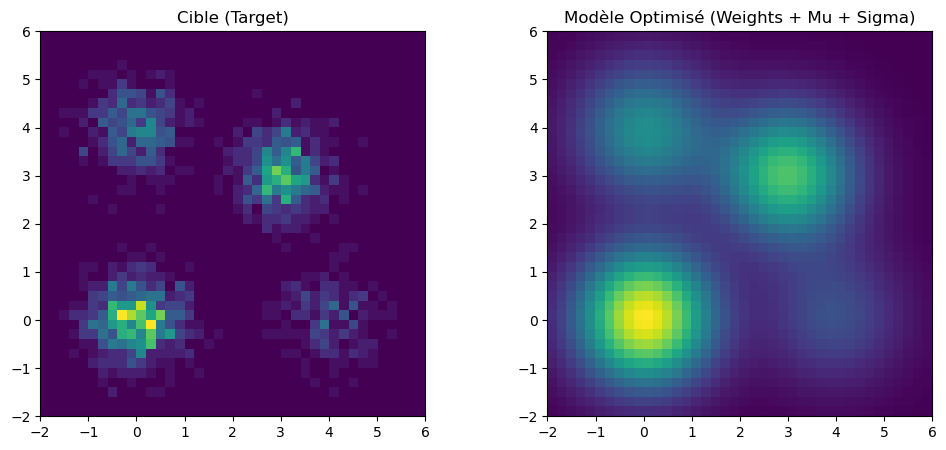

Poids finaux : [0.4014682  0.1996007  0.2996002  0.09933093]


In [112]:
# Récupération des paramètres optimisés
p_final = generer_modele_complet(poids_logits, mu_opt, L_opt).detach().reshape(taille_grille, taille_grille)
p_target_img = p_cible.reshape(taille_grille, taille_grille)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(p_target_img, origin='lower', extent=[-2, 6, -2, 6])
plt.title("Cible (Target)")

plt.subplot(1, 2, 2)
plt.imshow(p_final, origin='lower', extent=[-2, 6, -2, 6])
plt.title("Modèle Optimisé (Weights + Mu + Sigma)")
plt.show()

print("Poids finaux :", torch.softmax(poids_logits, dim=0).detach().numpy())